In [1]:
import torch
print(torch.__version__)

2.11.0+cpu


In [2]:
from datasets import load_dataset

dataset = load_dataset("imdb")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


The task performed is Sentiment Analysis, where the model classifies text as positive or negative.
The domain used is Movie Reviews, using the IMDb dataset.

In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [5]:
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length")

dataset = dataset.map(tokenize, batched=True)

In [10]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=1
)

In [11]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"].select(range(1000)),
    eval_dataset=dataset["test"].select(range(200))
)

trainer.train()

c:\Users\heral\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,0.002397


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\heral\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=125, training_loss=0.047384803771972656, metrics={'train_runtime': 1856.2789, 'train_samples_per_second': 0.539, 'train_steps_per_second': 0.067, 'total_flos': 132467398656000.0, 'train_loss': 0.047384803771972656, 'epoch': 1.0})

In [12]:
results = trainer.evaluate()
print(results)

Training Loss,Validation Loss,Epoch
No log,0.002397,1


{'eval_loss': 0.002397150034084916}


In [13]:
words = [
    "happy","sad","movie","film","actor","director",
    "good","bad","excellent","terrible",
    "love","hate","fun","boring",
    "story","plot","scene","music",
    "drama","comedy"
]

In [14]:
import torch

inputs = tokenizer(words, return_tensors="pt", padding=True, truncation=True)
outputs = model.base_model(**inputs)

embeddings = outputs.last_hidden_state.mean(dim=1).detach().numpy()

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

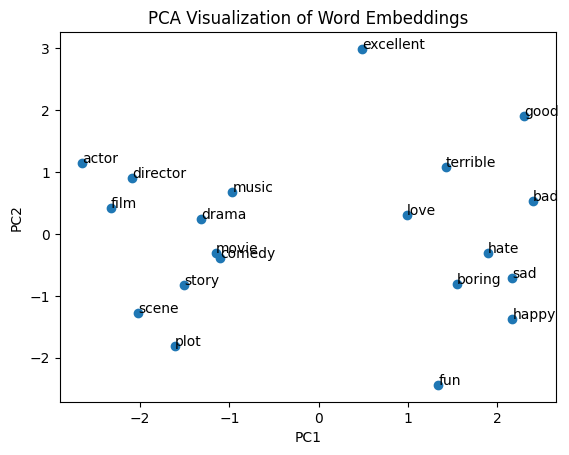

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, (reduced[i, 0], reduced[i, 1]))

plt.title("PCA Visualization of Word Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()